# Classify Defects on Wafer Maps Using Deep Learning

Wafers are thin disks of semiconducting material, typically silicon, that serve as the foundation for integrated circuits. Each wafer yields several individual circuits (ICs), separated into dies. Automated inspection machines test the performance of ICs on the wafer. The machines produce images, called wafer maps, that indicate which dies perform correctly (pass) and which dies do not meet performance standards (fail).

In semiconductor, there is a big problem how to classify the wafer map pattern into serveral groups without manual action. The defect recognition of wafers can be performed by using the real-world wafer map dataset (WM-811K), provided by Taiwan Semiconductor Manufacturing Company (TSMC) and built by Wu et al. Domain experts labeled some of these defect types on the wafers. The WM-811K is a dataset, which is the largest publicly available wafer map dataset to date and it can be downloaded from mirlab or Kaggle. The dataset is derived from the real production process of wafers.

Load the libraries needed for the project:

In [1]:
# First lets load all the libraries we are going to use
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import seaborn as sns
import cv2
import gc

Load the data inside a pandas data frame.

In [2]:
df=pd.read_pickle("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\project\\WM811K.pkl")

### Check the data Structure

In [8]:
df.info(memory_usage = "deep")

<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   dieSize         811457 non-null  float64
 1   failureType     811457 non-null  object 
 2   lotName         811457 non-null  object 
 3   trainTestLabel  811457 non-null  object 
 4   waferIndex      811457 non-null  float64
 5   waferMap        811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 334.3 MB


#### WaferMap visualization

Display one instance of the data to see what the data actually looks like.
I also added a command to display the waferMap.

dieSize                                                      1683.0
failureType                                                    none
lotName                                                        lot1
trainTestLabel                                             Training
waferIndex                                                      1.0
waferMap          [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
Name: 0, dtype: object


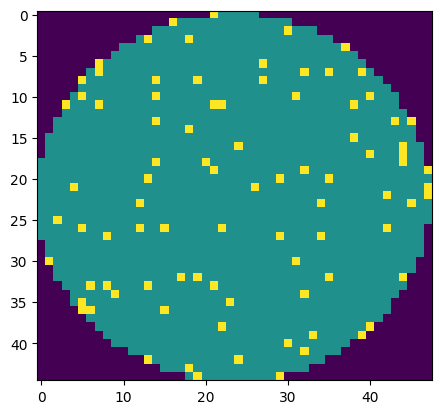

In [ ]:
print(df.iloc[0])
plt.imshow(df.iloc[0]['waferMap'],)

### Data Cleaning

Create the training and testing datasets by using the labels of the "trainTestLabel" attribute.

In [ ]:
df["trainTestLabel"].explode().value_counts()

trainTestLabel
0           1277014
Test         118595
Training      54355
Name: count, dtype: int64

There are only 172,950 unlabelled instances, 118595 testing instances and 54355 training instances. It is preferable to have more training instances than testing instances, so we will create a new data frame with both training and testing labels shuffled and relabelled to obtain 90% training samples and 10% testing samples. 

Before we create the new training and test datasets we will create a new dataset containing only the labelled samples.

In [9]:
index = []

for element in df["trainTestLabel"]:
    # we make sure the element is a string before checking whether the label is either Test or Training.
    # If that is not the case we proceed to append a False boolean to our index.
    if type(element) == type("string"):
        if element == "Training":
            index.append(True)
        else:
            index.append(False)
    else:
        index.append(False)

In [13]:
Training = df.iloc[index]

In [25]:
Original_training = Training[["waferMap","failureType"]].copy()

In [14]:
eda = pd.DataFrame(Training["failureType"].explode().value_counts())
eda["prop (%)"] = round(eda["count"] / sum(eda["count"]), 4) * 100
print(eda)

             count  prop (%)
failureType                 
none         36730     67.57
Edge-Ring     8554     15.74
Center        3462      6.37
Edge-Loc      2417      4.45
Loc           1620      2.98
Random         609      1.12
Scratch        500      0.92
Donut          409      0.75
Near-full       54      0.10


In [4]:
NewDataset = df.iloc[index]
print(NewDataset["trainTestLabel"].explode().value_counts())

trainTestLabel
Test        118595
Training     54355
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

TrainDataFrame, TestDataFrame = train_test_split(
    NewDataset,
    test_size=0.10, 
    random_state=42,  # for reproducibility
    stratify=NewDataset['failureType']
)

IMPORTANT NOTE: We use the .copy() method to create a copy of the filtered data, if we don't do this both dataframes will keep ponting at the data of the original dataset.

In [6]:
TrainDataFrame = TrainDataFrame[["waferMap","failureType"]].copy()
TestDataFrame = TestDataFrame[["waferMap","failureType"]].copy()

A quick check to ensure everything went accordingly

In [24]:
print(df["trainTestLabel"].explode().value_counts())
print(f"\nThe training set has {TrainDataFrame.shape} instances.")
print(f"The test set has {TestDataFrame.shape} instances.")

trainTestLabel
0           1277014
Test         118595
Training      54355
Name: count, dtype: int64

The training set has (155655, 2) instances.
The test set has (17295, 2) instances.


Before we continue we will delete from memory the original data frame df to free up +300MB of memory, which is additional memory the machine will be able to use during training and testing.

In [7]:

# 1. Delete the variables for the original dataset 
# (Replace 'original_dataset' and 'copied_dataset' with your actual variable names)
del df

# If you still have the intermediate copy variable lingering around, delete it too:
# del copied_dataset 

# 2. Force Python's Garbage Collector to run immediately and reclaim the RAM
gc.collect()

print("Original dataset deleted. +300MB of memory has been freed!")

Original dataset deleted. +300MB of memory has been freed!


### Data Exploration

The main porpouse of the research is to create a Deeep Neural Network that can properly classify wafers, so we will start by looking at the different classes of "failureType".

First we will plot the wafer maps for each failure type to actually visualize the different failure types

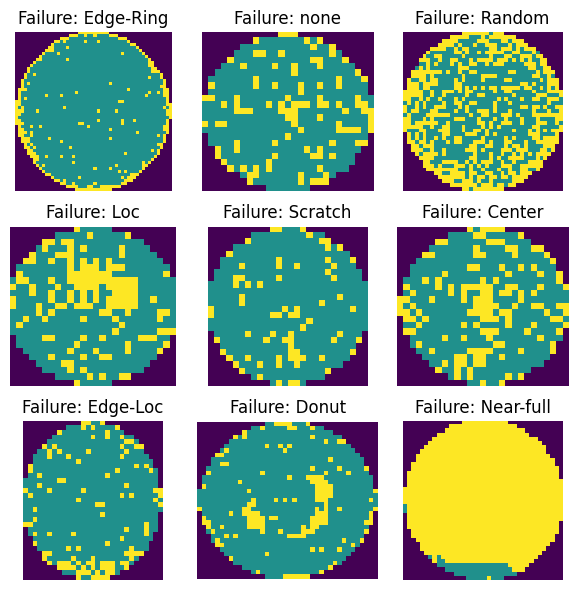

In [25]:
# Get the unique failure types from your dataframe
unique_failures = TrainDataFrame["failureType"].unique()

# Set up a 3x3 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(6, 6))

# Flatten the axes array to make iterating over it easier
axes = axes.ravel()

for i, failure in enumerate(unique_failures):
    # Filter the dataframe for the current failure type and grab the first row
    sample_row = TrainDataFrame[TrainDataFrame["failureType"] == failure].iloc[0]
    
    # Plot the wafermap using imshow
    axes[i].imshow(sample_row["waferMap"], cmap='viridis')
    axes[i].set_title(f"Failure: {failure}")
    axes[i].axis('off') # Turns off the x and y axes ticks for a cleaner look

# Adjust layout so the titles don't overlap
plt.tight_layout()
plt.show()

Now we will look at the absolute and relative frequencies of each class to check if there are any class imbalances

In [26]:
eda = pd.DataFrame(TrainDataFrame["failureType"].explode().value_counts())
eda["prop (%)"] = round(eda["count"] / sum(eda["count"]), 4) * 100
print(eda)

              count  prop (%)
failureType                  
none         132688     85.24
Edge-Ring      8712      5.60
Edge-Loc       4670      3.00
Center         3865      2.48
Loc            3234      2.08
Scratch        1074      0.69
Random          779      0.50
Donut           499      0.32
Near-full       134      0.09


There are 9 failure types with "none" indicating the wafers that have none pattern.
The classes are highly imbalanced because 85.24% of the instances show no pattern in their defects while half of the classes, namely "Donut", "Random", "Scratch" and "Near-full" represent less than 2% of the training set.

### Data Preparation for Training

We create the X_train dataset containing only the waferMaps of our samples because we are interested on building a network that can correctly identify the the failure type of a wafer by looking at its map. We create the y_train dataset with the labels of the test data.

In [8]:
X_train = TrainDataFrame["waferMap"].tolist()
y_train = TrainDataFrame["failureType"].tolist()

The last steps before we can finally plug the input data in a neural network are the following:
- image resizing: the wafermaps don't all share the same size, so we must ensure all of them are the shape.
- one-hot encoding: the single values stored in the 2-D array representing the wafermaps cannot be fed into a DNN that works in 3-D inputs. One way to solve this issue is by using one-hot encoding, which basically means creating a binary attribute for each of the three possible pixel values.
- data augmentation: the data is highly imbalanced, the vast majority of our dataset belongs to the none failure type, which means a DNN that can accurately classify the none class can achieve an overall high accuracy on the test dataset regardless of how well it can classify all other classes. 

#### Undersampling

We need to the undersample our data because when using data augmentation if we consider the fact that the majority class has well over 132000 samples it will result into the  generation of an extremely high number of samples for the minority classes, multiplying by several times their original sizes with new syntethic samples. All of this, in turn,  would lead to high execution times for the data augmentation function, which might even take more than 30 minutes on our laptops. For this reason we will downsample the majority classes to 3234 samples, which is the absolute frequency for "Loc", the fifth most common class. The reason for choosing "Loc" as a reference for the number of samples is that we will need to generate new samples only for half of the classes while still keeping a relatively high number instances for the majority classes.

In [21]:
def undersample_raw_data(raw_wafers, raw_labels, max_cap=3234):
    """
    Undersamples raw lists of images and string labels before any processing.
    """
    # Convert labels to a NumPy array so we can easily search it
    labels_arr = np.array(raw_labels)
    unique_classes = np.unique(labels_arr)
    
    keep_indices = []
    
    for cls in unique_classes:
        # Find all indices belonging to this specific string label
        class_indices = np.where(labels_arr == cls)[0]
        num_samples = len(class_indices)
        
        if num_samples > max_cap:
            # Randomly select a subset to keep
            selected = np.random.choice(class_indices, size=max_cap, replace=False)
            keep_indices.extend(selected)
            print(f"Class '{cls}': Cut from {num_samples} down to {max_cap}")
        else:
            # Keep all of them
            keep_indices.extend(class_indices)
            print(f"Class '{cls}': Kept all {num_samples} samples")
            
    # Shuffle the indices so the classes are mixed
    np.random.shuffle(keep_indices)
    
    # Extract only the surviving wafers and labels using list comprehension
    surviving_wafers = [raw_wafers[i] for i in keep_indices]
    surviving_labels = [raw_labels[i] for i in keep_indices]
    
    return surviving_wafers, surviving_labels

In [12]:
shrunk_wafers, shrunk_labels = undersample_raw_data(X_train, y_train, max_cap=3234)

Class 'Center': Cut from 3865 down to 3234
Class 'Donut': Kept all 499 samples
Class 'Edge-Loc': Cut from 4670 down to 3234
Class 'Edge-Ring': Cut from 8712 down to 3234
Class 'Loc': Kept all 3234 samples
Class 'Near-full': Kept all 134 samples
Class 'Random': Kept all 779 samples
Class 'Scratch': Kept all 1074 samples
Class 'none': Cut from 132688 down to 3234


Let's check the class distributions after the undersampling.

In [12]:
from collections import Counter

total_items = len(shrunk_labels)

# 1. Get absolute frequencies
counts = Counter(shrunk_labels)

# 2. Print table header
print(f"{'Value':<12} | {'Abs Freq':<10} | {'Rel Freq':<10}")
print("-" * 40)

# 3. Calculate relative frequency and print rows
for item, abs_freq in counts.items():
    rel_freq = abs_freq / total_items
    # :<12 means left-align with 12 spaces; :.2% formats as a percentage
    print(f"{item:<12} | {abs_freq:<10} | {rel_freq:<10.2%}")

Value        | Abs Freq   | Rel Freq  
----------------------------------------
none         | 3234       | 17.33%    
Edge-Loc     | 3234       | 17.33%    
Center       | 3234       | 17.33%    
Edge-Ring    | 3234       | 17.33%    
Scratch      | 1074       | 5.76%     
Loc          | 3234       | 17.33%    
Near-full    | 134        | 0.72%     
Random       | 779        | 4.18%     
Donut        | 499        | 2.67%     


### One-Hot Encoding the Labels
We are working with a categorical target class so we will encode the labels into 9 different categories.

We are going to perform One-Hot encoding several times so we will create a OneHotEncoding function to make the task easier.

In [13]:
def OneHotEncoding(dataset):
    unique_classes = sorted(list(set(dataset))) 
    # Result: ['Center', 'Donut', 'Edge-Ring', 'Scratch']

    # Create a dictionary mapping: {'Center': 0, 'Donut': 1, ...}
    label_to_int = {classname: idx for idx, classname in enumerate(unique_classes)}
    print("Your Class Mapping:", label_to_int)

    # Perform One-Hot Encoding
    num_classes = 9 # Total classes in your full dataset
    encoded_labels = []

    for label in dataset:
    # Get the integer ID for this string
        label_id = label_to_int[label]
    
        # Create the 9-channel one-hot list
        one_hot = [0] * num_classes
        one_hot[label_id] = 1
    
        encoded_labels.append(one_hot)

    # Let's see what "Donut" looks like now
    print(f"\nString: {dataset[1]} -> One-Hot: {encoded_labels[1]}")
    return encoded_labels

In [14]:
encoded_labels = OneHotEncoding(shrunk_labels)

Your Class Mapping: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8}

String: Edge-Loc -> One-Hot: [0, 0, 1, 0, 0, 0, 0, 0, 0]


We will create a dictionary containing the keys from the dictionary used to map the categorical labels into encoded labels, the reason for this is that later we will need to switch our encoded labels back to their original categorical values.

In [15]:
ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]

### Wafer Standardization (Image Resizing)
The wafermaps' shape varies greatly among the samples, so in order to standardized their size, first we will look at the wafermaps' size distribution.

In [19]:
def sizes(wafers):
    wafershapes = []

    for element in wafers:
        wafershapes.append([len(element), len(element[0])])

    wafershapes = pd.Series(wafershapes)
    shape_freq = wafershapes.value_counts()
    print(shape_freq[:5])

In [16]:
# Lets figure out the sizes of all the wafermaps in the dataset downsampled to 3462 samples for the majority classes 
sizes(shrunk_wafers)

[25, 27]    2534
[26, 26]    1000
[39, 37]     925
[30, 34]     788
[38, 36]     684
Name: count, dtype: int64


Ww look at the size distribution wuth the data undersampled using as a max cap the number of instances of Edge-Loc, the third most frequent class.

In [42]:
shrunk_wafers2, shrunk_labels2 = undersample_raw_data(X_train, y_train, max_cap=4670)

Class 'Center': Kept all 3865 samples
Class 'Donut': Kept all 499 samples
Class 'Edge-Loc': Kept all 4670 samples
Class 'Edge-Ring': Cut from 8712 down to 4670
Class 'Loc': Kept all 3234 samples
Class 'Near-full': Kept all 134 samples
Class 'Random': Kept all 779 samples
Class 'Scratch': Kept all 1074 samples
Class 'none': Cut from 132688 down to 4670


In [43]:
# Lets figure out the sizes of all the wafermaps in the dataset downsampled to 4670 samples for the majority classes 
sizes(shrunk_wafers2)

[25, 27]    3116
[26, 26]    1223
[39, 37]    1198
[38, 36]    1001
[30, 34]     958
Name: count, dtype: int64


In [44]:
#Let's look at the frequencies of the wafermap sizes in the original dataset
sizes(X_train)

[25, 27]    16912
[26, 26]    12881
[30, 34]    11154
[29, 26]    10590
[27, 25]     9588
Name: count, dtype: int64


If we take a look at the top 5 most frequent image sizes in both of the downsampled datasets we will find that the biggest wafermap (the one with the most pixels) is [39, 37].
Let's see the fraction of samples with a shape smaller or equal than [39, 37]. 

In [ ]:
wafershapes = []

for element in shrunk_wafers:
    wafershapes.append([len(element), len(element[0])])

wafershapes = pd.Series(wafershapes)
shape_freq = wafershapes.value_counts()

counter = 0
for shape in wafershapes:
    if shape[0] <= 39 and shape[1] <= 37:
        counter += 1

print(counter/ sum(shape_freq))

0.5766509433962265


In [52]:
#Lets find the highest and widest wafermaps in the training dataset
max_width = 0
max_height = 0

for index, shape in enumerate(wafershapes):
    if shape[0] > max_height:
        max_height = shape[0]
    if shape[1] > max_width:
        max_width = shape[1]

print(f"The highest map is: {max_height} pixels")
print(f"The widest map is: {max_width} pixels")

The highest map is: 212 pixels
The widest map is: 204 pixels


Around 42% (1 - 0.58) of the wafermaps have a shape smaller or equal to [39, 37], which means that if we standardize the samples in a [39, 37] shape almost half of the samples will lose wafermap data as they are being reduced. We could bring to zero the number of reduced samples by just using a shape with the maximum values for both width and height [212, 204]. The only problem with this approach is that it would increase by more than 30 times ((212/37) x (204/37)) the number of pixels for more than half of the samples, leading to an a significant increase in the memory usage. A better approach is to select a wafershape that is bigger than most of our training wafermaps, but still small enough not to require too much memory to store the augmented wafermaps.

In [13]:
wafershapes = []

for element in X_train:
    wafershapes.append([len(element), len(element[0])])

wafershapes = pd.Series(wafershapes)
shape_freq = wafershapes.value_counts()

counter = 0

for shape in wafershapes:
    if shape[0] <= 54 and shape[1] <= 54:
        counter += 1

print(counter/ sum(shape_freq))

0.9581060679065883


In [27]:
shrunk_wafers_og, shrunk_label_og = undersample_raw_data(Original_training["waferMap"].tolist(), Original_training["failureType"].tolist(), max_cap=3462)

wafershapes = []

for element in shrunk_wafers_og:
    wafershapes.append([len(element), len(element[0])])

wafershapes = pd.Series(wafershapes)
shape_freq = wafershapes.value_counts()

counter = 0

for shape in wafershapes:
    if shape[0] <= 54 and shape[1] <= 54:
        counter += 1

print(counter/ sum(shape_freq))

Class 'Center': Kept all 3462 samples
Class 'Donut': Kept all 409 samples
Class 'Edge-Loc': Kept all 2417 samples
Class 'Edge-Ring': Cut from 8554 down to 3462
Class 'Loc': Kept all 1620 samples
Class 'Near-full': Kept all 54 samples
Class 'Random': Kept all 609 samples
Class 'Scratch': Kept all 500 samples
Class 'none': Cut from 36730 down to 3462
0.7969365426695842


In [55]:
counter = 0
for shape in wafershapes:
    if shape[0] <= 54 and shape[1] <= 54:
        counter += 1

print(counter/ sum(shape_freq))

0.8665308747855918


After a few trials we will select a 54x54 shape because of the following two reasons:
- A 54x54 wafermap is bigger than more than 86% of the samples, which means only less than 14% of the samples will lose information as a result of reduction.
- a square picture can be flipped by keeping its shape unchanged, which helps during data augmentation.

We create a function called standardize_wafermap to perform both padding and image interpolation on the wafermaps.

In [26]:
def standardize_wafermap(wafer_3d, target_shape=(54, 54), pad_vector=[1, 0, 0]):
    """
    Pads and reduces a ONE-HOT ENCODED wafermap (3D array).
    pad_vector defaults to [1, 0, 0] assuming category 0 is the background.
    """
    h, w, channels = wafer_3d.shape
    th, tw = target_shape
    
    # CONDITION 1: Reduce if larger than 38x36
    if h > th or w > tw:
        scale = min(tw / w, th / h)
        new_w = int(w * scale)
        new_h = int(h * scale)
        
        # Resize using INTER_NEAREST to keep strict 0s and 1s in the channels
        processed_wafer = cv2.resize(wafer_3d, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        
    # CONDITION 2: Keep size if smaller/equal
    else:
        processed_wafer = wafer_3d
        new_h, new_w, _ = processed_wafer.shape
        
    # --- PADDING STEP ---
    
    # 1. Create a 38x36x3 canvas. 
    # We initialize with zeros, then broadcast the pad_vector to every pixel.
    canvas = np.zeros((th, tw, channels), dtype=wafer_3d.dtype)
    canvas[:] = pad_vector 
    
    # 2. Calculate centering offsets
    y_offset = (th - new_h) // 2
    x_offset = (tw - new_w) // 2
    
    # 3. Paste the processed 3D wafer onto the canvas
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = processed_wafer
    
    return canvas

We define the FullWaferStandardization function to perform shape standardization and one-hot encoding of the wafermaps.

One-Hot Encoding transforms the single 2D channel into 3 separate channels (one for each category: 0, 1, and 2).
- Channel 0 will have a 1 where the pixel was 0, and 0 everywhere else. It defines whether that location in the wafermap is the background.
- Channel 1 will have a 1 where the pixel was 1, and 0 everywhere else. It tells if the die in that location is working.
- Channel 2 will have a 1 where the pixel was 2, and 0 everywhere else. It tells if the die in that location is not working.

This successfully builds a 3D array: (Height, Width, 3).


In [25]:
def FullWaferStandardization(wafers):
# Assuming 'raw_wafermaps' is a list of your 2D arrays with varying sizes
    processed_wafers = []   
    target_size = (54, 54)

    for raw_wafer in wafers:
    
    # STEP 1: One-Hot Encode First
    # This turns a (H, W) array of 0s, 1s, 2s into a (H, W, 3) array of 0s and 1s.
    # (We use np.eye to do this fast without external deep learning libraries)
        one_hot_wafer = np.eye(3, dtype=np.float32)[raw_wafer] 
    
    # STEP 2: Standardize the 3D array
        standardized_wafer = standardize_wafermap(
            one_hot_wafer, 
            target_shape=target_size, 
            pad_vector=[1, 0, 0] # Background category vector
        )
    
        processed_wafers.append(standardized_wafer)

# Convert the list to your final training batch
# Shape will be: (num_samples, 54, 54, 3)
    return np.array(processed_wafers)

In [18]:
X_train_final = FullWaferStandardization(shrunk_wafers)
print(f"Final dataset shape: {X_train_final.shape}")

Final dataset shape: (18656, 54, 54, 3)


Lets take look at standardized and encoded wafermaps:

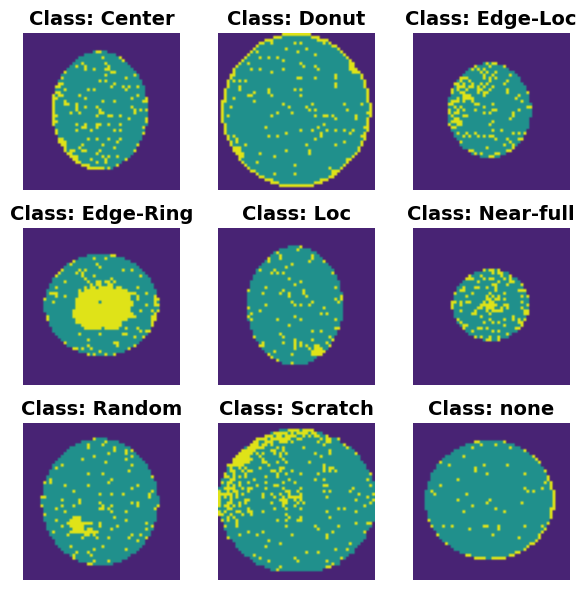

In [66]:
# 1. Prepare labels and find first occurrences
y_train_flat = np.array(y_train).ravel()
unique_classes, indices = np.unique(y_train_flat, return_index=True)

# 2. Set up the 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(6, 6))
axes = axes.ravel()

# 3. Dynamically extract RGB vectors from the viridis colormap
# We sample at 0.1 (dark purple), 0.5 (green), and 0.95 (bright yellow)
# [:3] discards the alpha (transparency) channel, leaving just [R, G, B]
cmap = plt.get_cmap('viridis')
color_0 = np.array(cmap(0.1)[:3])   # Replaces Channel 0 (e.g., Background)
color_1 = np.array(cmap(0.5)[:3])   # Replaces Channel 1 (e.g., Normal Die)
color_2 = np.array(cmap(0.95)[:3])  # Replaces Channel 2 (e.g., Defect/Failure)

# 4. Loop through and apply the color matrix transformation
for i in range(9):
    idx = indices[i]
    class_label = unique_classes[i]
    
    # Grab the original (54, 54, 3) image and cast to float
    img = X_train_final[idx].astype(float)
    
    # Normalize to [0, 1] if the data is currently 0-255 integer format
    if img.max() > 1.0:
        img /= 255.0
        
    # Remap channels: Blend each channel mask with its assigned viridis color
    custom_img = (
        img[:, :, 0:1] * color_0 + 
        img[:, :, 1:2] * color_1 + 
        img[:, :, 2:3] * color_2
    )
    
    # Clip values to keep them strictly within valid bounds [0.0, 1.0]
    custom_img = np.clip(custom_img, 0, 1)
    
    # Plot the viridis-colored image
    axes[i].imshow(custom_img)
    axes[i].set_title(f"Class: {class_label}", fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Data augmentation
The data is finally in the format needed to be fed to a DNN. We can now tackle the issue of class imbalance that we encountered earlier.
We are going to create a function that performs the following transformations in order to create more samples:
- flipping the picture horizontally or vertically
- rotate the picture by a multiple of 90°
- add random noise by flipping either channel 1 or channel 2, channel 0 is left untouched because it is the background.

#### The Augmentation Function (Single Wafer)

The Data Augmentation function creates a new syntethic sample from an input sample by taking the original sample and perform a series of operations (the ones mentioned previously).

In [24]:
def augment_wafermap(wafer_3d, label_1d, noise_prob=0.05):
    """
    Applies rotation, mirroring, and channel-swapping noise to a single wafermap.
    wafer_3d shape: (54, 54, 3)
    label_1d shape: (9,)
    """
    # Create a copy so we don't permanently alter the original array in memory
    aug_wafer = np.copy(wafer_3d)
    
    # --- 1. ROTATE ---
    # Randomly rotate by 0, 90, 180, or 270 degrees
    k_rotations = np.random.randint(0, 4)
    aug_wafer = np.rot90(aug_wafer, k=k_rotations)
    
    # --- 2. MIRROR / FLIP ---
    # 50% chance to flip horizontally (left to right)
    if np.random.rand() > 0.5:
        aug_wafer = np.fliplr(aug_wafer)
        
    # 50% chance to flip vertically (top to bottom)
    if np.random.rand() > 0.5:
        aug_wafer = np.flipud(aug_wafer)
        
    # --- 3. CHANNEL NOISE (Channels 1 & 2 Only) ---
    # Find all pixels that are NOT the background 
    # (i.e., where Channel 0 is exactly 0)
    defect_mask = aug_wafer[:, :, 0] == 0 
    
    # Create a random boolean mask based on your noise probability
    # If noise_prob is 0.05, ~5% of pixels will be flagged as True
    random_flip_mask = np.random.rand(aug_wafer.shape[0], aug_wafer.shape[1]) < noise_prob
    
    # We only want to flip pixels that are BOTH a defect AND selected by the random mask
    pixels_to_flip = defect_mask & random_flip_mask
    
    # Swap Channel 1 and Channel 2 for those specific pixels.
    # A [0, 1, 0] becomes [0, 0, 1], and a [0, 0, 1] becomes [0, 1, 0].
    # Channel 0 is completely untouched!
    temp_channel = aug_wafer[pixels_to_flip, 1].copy()
    aug_wafer[pixels_to_flip, 1] = aug_wafer[pixels_to_flip, 2]
    aug_wafer[pixels_to_flip, 2] = temp_channel

    # The label remains exactly the same for the augmented image
    return aug_wafer, label_1d

#### Expansion Function

The Expansion Function performs data augmentation on all wafermaps and returns the expanded dataset.

In [20]:
def expand_dataset_by_class(X, y, augmentation_map, noise_prob=0.05):
    """
    Expands the dataset using a specific number of augmentations per class.
    
    augmentation_map: A dictionary like {0: 0, 1: 5, 2: 10...} 
                      where the key is the class index and the value 
                      is the number of new augmented copies to make.
    """
    X_expanded = []
    y_expanded = []
    
    for i in range(len(X)):
        # 1. Always keep the original sample
        X_expanded.append(X[i])
        y_expanded.append(y[i])
        
        # 2. Figure out the integer class ID from the one-hot label
        class_idx = np.argmax(y[i])
        
        # 3. Look up how many augmentations this specific class needs
        # (Defaults to 0 if the class isn't in the dictionary)
        num_augmentations = augmentation_map.get(class_idx, 0)
        
        # 4. Generate the required number of augmented copies
        for _ in range(num_augmentations):
            # Calling the augment_wafermap function we built previously!
            aug_x, aug_y = augment_wafermap(X[i], y[i], noise_prob=noise_prob)
            X_expanded.append(aug_x)
            y_expanded.append(aug_y)
            
    return np.array(X_expanded), np.array(y_expanded)

#### The Auto-Balancer Function
Manually guessing how many augmentations each class needs is tedious. The helper function that looks at your dataset, finds the majority class, and calculates exactly how many augmentations the minority classes need so that every class ends up with roughly the same number of samples.

In [21]:
def calculate_balancing_map(y):
    """
    Calculates an augmentation map to balance all classes 
    to match the size of the largest class.
    """
    # Convert all one-hot labels back to a 1D array of integers
    y_integers = np.argmax(y, axis=1)
    
    # Count how many samples exist for each class
    class_counts = np.bincount(y_integers)
    
    # Find the size of the largest class
    majority_class_size = np.max(class_counts)
    #print(f"The majority class has {majority_class_size} samples")
    
    augmentation_map = {}
    
    for class_idx, count in enumerate(class_counts):
        if count == 0:
            continue # Skip classes that have zero samples
            
        # How many MORE samples do we need to catch up to the majority?
        samples_needed = majority_class_size - count
        
        # Divide by the number of original samples we have to get the multiplier
        # Using integer division (//) so we don't get partial augmentations
        aug_per_sample = samples_needed // count
        
        augmentation_map[class_idx] = aug_per_sample
        
        print(f"Class {class_idx}: has {count} samples. Generating {aug_per_sample} augs/sample.")
        
    return augmentation_map

#### Final Pipeline
This final pipeline combines all the functions required for the data augmentation

In [22]:
print("\n--- STEP 1: CALCULATING NEW BALANCING MULTIPLIERS ---")
# This auto-calculates based on the new MAX_CAP max size
auto_map = calculate_balancing_map(encoded_labels)


print("\n--- STEP 2: AUGMENTING MINORITY CLASSES ---")
# This will now run lightning fast because minority classes only have to catch up to MAX_CAP!
X_balanced, y_balanced = expand_dataset_by_class(
    X_train_final, 
    encoded_labels, 
    augmentation_map=auto_map, 
    noise_prob=0.04
)

print(f"\n🚀 FINAL TRAIN DATA SHAPE: {X_balanced.shape}")
print(f"🚀 FINAL LABELS SHAPE:     {y_balanced.shape}")


--- STEP 1: CALCULATING NEW BALANCING MULTIPLIERS ---
Class 0: has 3234 samples. Generating 0 augs/sample.
Class 1: has 499 samples. Generating 5 augs/sample.
Class 2: has 3234 samples. Generating 0 augs/sample.
Class 3: has 3234 samples. Generating 0 augs/sample.
Class 4: has 3234 samples. Generating 0 augs/sample.
Class 5: has 134 samples. Generating 23 augs/sample.
Class 6: has 779 samples. Generating 3 augs/sample.
Class 7: has 1074 samples. Generating 2 augs/sample.
Class 8: has 3234 samples. Generating 0 augs/sample.

--- STEP 2: AUGMENTING MINORITY CLASSES ---

🚀 FINAL TRAIN DATA SHAPE: (28718, 54, 54, 3)
🚀 FINAL LABELS SHAPE:     (28718, 9)


Lets perform a quick check to see the distribution of the classes.

In [23]:
# Lets create a numpy aray containing the names of the classes
# ATTENTION: we are using the shrunk_labels dataset to generate the list of the
#            class names because the encoding was performed with that data. If we
#            used the balanced data the names of the classes would be arranged
#            in a different order leading to assigning the wrong name to the 
#            one-hot encoded attribute

class_names = np.array(ClassMapping)

# axis=1 tells NumPy to look across the columns of each row to find the '1'
class_indices = np.argmax(y_balanced, axis=1)

# Map the integer indices back to your actual class string names
# (This requires class_names to be a NumPy array for "fancy indexing")
decoded_labels = class_names[class_indices]

# --- Viewing the Distribution ---
# return_counts=True automatically tallies up the occurrences of each class
unique_classes, counts = np.unique(decoded_labels, return_counts=True)

# Display the results
print("Class Distribution:")
print("-" * 25)
for cls, count in zip(unique_classes, counts):
    print(f"{cls:<10} | {count} samples")

Class Distribution:
-------------------------
Center     | 3234 samples
Donut      | 2994 samples
Edge-Loc   | 3234 samples
Edge-Ring  | 3234 samples
Loc        | 3234 samples
Near-full  | 3216 samples
Random     | 3116 samples
Scratch    | 3222 samples
none       | 3234 samples


The classes are now equally distributed. The data is now ready to be fed to a DNN by using X_balanced as training samples and y_balanced as labels.


We save the balanced data in two files for later retrieval.

In [24]:
np.save('X_balanced.npy', X_balanced)
np.save('y_balanced.dat', y_balanced)

## Training

At first we will train the ModelV1 on a downsampled training dataset, with a max cap of 8712 samples, which means we are downsampling the majority class. Using  the full dataset is not feasible because it is too heavy to be loaded on our laptops. We preprocess the training data and labels so they can be in the correct format required by the Neural Network.

In [14]:
shrunk_wafers, shrunk_labels = undersample_raw_data(X_train, y_train, max_cap=8712)

Class 'Center': Kept all 3865 samples
Class 'Donut': Kept all 499 samples
Class 'Edge-Loc': Kept all 4670 samples
Class 'Edge-Ring': Kept all 8712 samples
Class 'Loc': Kept all 3234 samples
Class 'Near-full': Kept all 134 samples
Class 'Random': Kept all 779 samples
Class 'Scratch': Kept all 1074 samples
Class 'none': Cut from 132688 down to 8712


In [15]:
Training_data = FullWaferStandardization(shrunk_wafers)

In [16]:
print("Train pixel range:", Training_data.min(), "to", Training_data.max())

Train pixel range: 0.0 to 1.0


In [17]:
Training_data[0]

array([[[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]],

       ...,

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]],

       [[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]]], shape=(54, 54, 3), dtype=float32)

In [18]:
Training_labels = np.array(OneHotEncoding(shrunk_labels))

Your Class Mapping: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8}

String: Edge-Ring -> One-Hot: [0, 0, 0, 1, 0, 0, 0, 0, 0]


In [19]:
Training_labels.shape

(31679, 9)

I save the Training data and the Training labels in two files so I can retrieve them without the need of going through the entire pipeline every single time.

In [19]:
np.save('Training_data.npy', Training_data)
np.save('Training_labels.dat', Training_labels)

### Testing Dataset
Before testing it is necessary to one-hot encode the test dataset.

In [22]:
X_test = TestDataFrame["waferMap"].tolist()
y_test = TestDataFrame["failureType"].tolist()

In [27]:
X_test = FullWaferStandardization(X_test)
print(f"Final dataset shape: {X_test.shape}")

Final dataset shape: (17295, 54, 54, 3)


In [28]:
y_test = OneHotEncoding(y_test)

Your Class Mapping: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8}

String: none -> One-Hot: [0, 0, 0, 0, 0, 0, 0, 0, 1]


We save the original testing data (X_test) and the labels (y_test) on two separate files. The motivation for this is that we can avoid going through the whole preprocessing phase, which includes loading the original dataset and then deleting it, any time we need the testing data.

In [ ]:
np.save('y_test.npy', y_test)
np.save("X_test.dat", X_test)

### Model Architecture (ModelV1)

Explain the model architecture.

In [24]:
# --- 1. Define Shapes Based on the input Data ---
input_shape = (54, 54, 3)  # 3 channels per pixel
num_classes = 9           # 9 attributes, one-hot encoded

modelv1 = models.Sequential([
    # Input & MATLAB-style normalization (Min=0, Max=2)
    layers.Input(shape=input_shape),
    layers.Rescaling(scale=1.0/2.0), 
    
    # Block 1: 54x54x3 -> 27x27x8 after MaxPool
    layers.Conv2D(8, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2: 27x27x8 -> 13x13x16 after MaxPool
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3: 13x13x16 -> 6x6x32 after MaxPool
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 4: Stays 6x6x64
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    layers.Dropout(0.5),
    layers.Flatten(),                  # Flattens 6x6x64 into a 2304-element vector
    layers.Dense(num_classes),         # 9 outputs
    layers.Activation('softmax')
])

In [25]:
modelv1.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Training on Original dataset

We train ModelV1 on the original training dataset.

We load the testing dataset to look at the model's loss function during training to help visualize whether the network is overfitting or underfitting.

In [25]:
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy')
print("Data successfully linked via Memory Map.")

Data successfully linked via Memory Map.


In [27]:
history = modelv1.fit(
    x=Training_data,                      # Your 54x54x3 training images
    y=Training_labels,                      # Your one-hot encoded labels
    epochs=30,                      # MaxEpochs=30
    batch_size=128,                 # MiniBatchSize=128
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch
    
    # --- Handling the Validation Data ---
    # Option A: If you have a SEPARATE validation dataset/labels, uncomment the line below:
    validation_data=(X_test, y_test) 
)

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.7524 - loss: 0.7277 - val_accuracy: 0.0665 - val_loss: 1.9866
Epoch 2/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.8589 - loss: 0.4051 - val_accuracy: 0.5230 - val_loss: 1.8005
Epoch 3/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.8800 - loss: 0.3408 - val_accuracy: 0.5697 - val_loss: 1.9769
Epoch 4/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.8908 - loss: 0.3095 - val_accuracy: 0.5771 - val_loss: 2.3878
Epoch 5/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.8976 - loss: 0.2804 - val_accuracy: 0.5727 - val_loss: 2.5074
Epoch 6/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9053 - loss: 0.2626 - val_accuracy: 0.5451 - val_loss: 2.7959
Epoch 7/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9114 - loss: 0.2500 - val_accuracy: 0.5667 - val_loss: 2.3813
Epoch 8/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.9149 - loss: 0.2339 - 

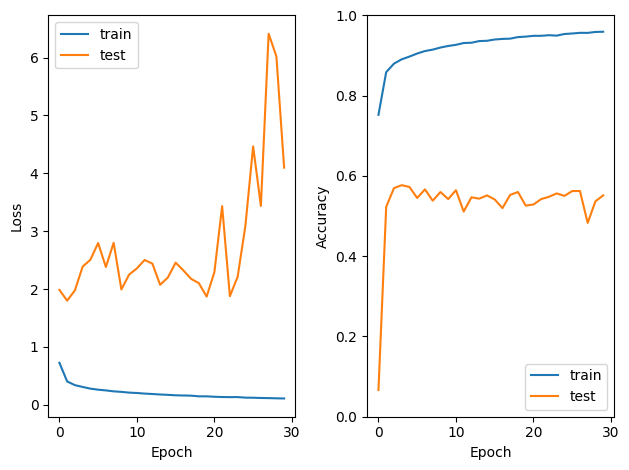

In [30]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'test'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

plt.tight_layout()

We save the model and the history object on a separate files for later retrieval. This will remove the need of going through the whole preprocessing pipeline and training (which takes on average 30 minutes on our laptops) every single time we start the notebook.

In [ ]:
modelv1.save("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\MIR-WM811K\\MIR-WM811K\\Python\\modelv1.keras")

In [32]:
# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history.history)

# Save to CSV
history_df.to_csv('history_modelv1.csv', index=False)

# --- To load it back later ---
loaded_df = pd.read_csv('history_modelv1.csv')

### Evaluation ModelV1

Now we can retrieve both the trained model and testing data directly from their files.

In [ ]:
model = tf.keras.models.load_model('modelv1.keras')
print("Model loaded.")

# 2. Point to the data on your drive (Takes 0 MB of RAM)
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy')
print("Data successfully linked via Memory Map.")

# 3. Test safely using a batch size
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Model loaded.
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5518 - loss: 4.0978

Final Test Accuracy: 55.18%


ModelV1 achieves a 55.18% accuracy on the test set if trained on the dataset with the majority class downsampled down to 8712 samples.

In [28]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = model.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 1 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


The overall accuracy is not a good indicator of the model's performance when dealing with multi-class classification with highly imbalanced data. A better and more detailed approach is to look at the model's confusion matrix and the recall on each class.

In [29]:
from sklearn.metrics import confusion_matrix

predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Recall:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Recall: {macro_accuracy * 100:.2f}%")

Per-Class Recall:
-------------------------
Class Center: 53.38%
Class Donut: 48.21%
Class Edge-Loc: 49.13%
Class Edge-Ring: 58.06%
Class Loc: 43.45%
Class Near-full: 66.67%
Class Random: 52.87%
Class Scratch: 90.76%
Class none: 55.28%
-------------------------
Average (Macro) Recall: 57.54%


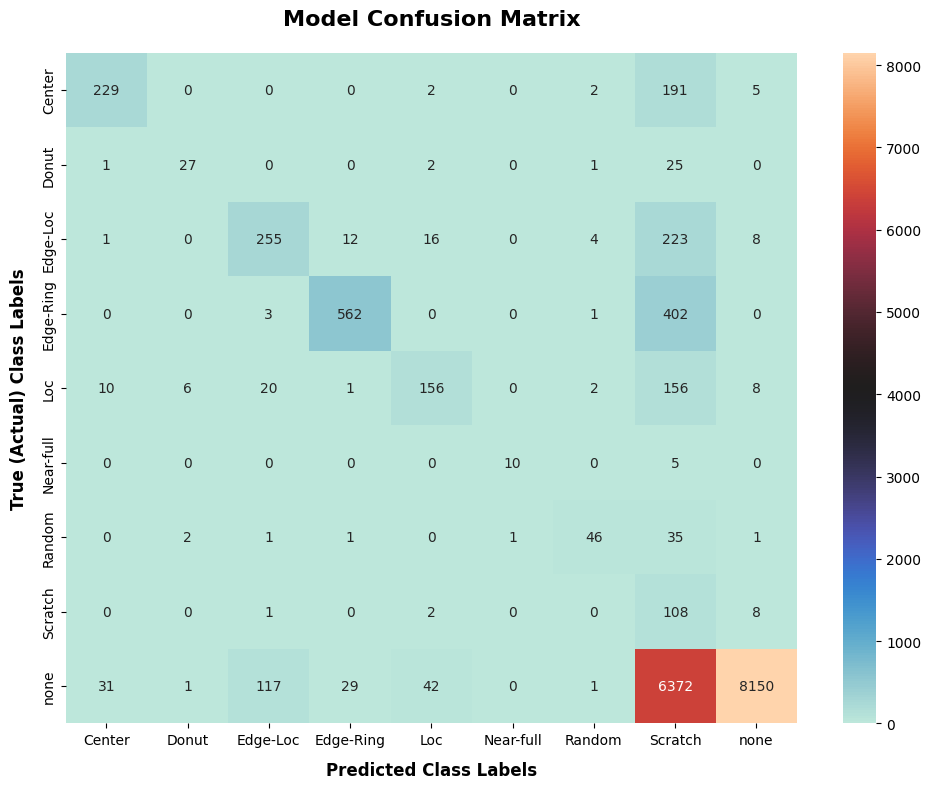

In [7]:
# 1. Calculate the raw confusion matrix numerical values
# (Assumes true_classes and predicted_classes are defined from the predict step)
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Set up the figure size (10x8 inches works well for 9 classes)
plt.figure(figsize=(10, 8))

# 3. Create the colored heatmap
# annot=True plots the numbers inside each square
# fmt='d' forces plain integer format (no scientific notation)
# cmap='Blues' applies a light-to-dark blue gradient based on the numbers
class_names = ClassMapping

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='icefire', 
    xticklabels=class_names, 
    yticklabels=class_names
)

# 4. Add clear labels and styling
plt.title('Model Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True (Actual) Class Labels', fontsize=12, fontweight='bold', labelpad=10)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# 5. Render the plot on your screen
plt.show()

### Model Architecture (ModelV1b)
We will reuse the architecture of ModelV1 but on the balanced data, we will call this model ModelV1b.

In [26]:
# --- 1. Define Shapes Based on the input Data ---
input_shape = (54, 54, 3)  # 3 channels per pixel
num_classes = 9           # 9 attributes, one-hot encoded

modelv1b = models.Sequential([
    # Input & MATLAB-style normalization (Min=0, Max=2)
    layers.Input(shape=input_shape),
    layers.Rescaling(scale=1.0/2.0), 
    
    # Block 1: 54x54x3 -> 27x27x8 after MaxPool
    layers.Conv2D(8, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2: 27x27x8 -> 13x13x16 after MaxPool
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3: 13x13x16 -> 6x6x32 after MaxPool
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 4: Stays 6x6x64
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    layers.Dropout(0.5),
    layers.Flatten(),                  # Flattens 6x6x64 into a 2304-element vector
    layers.Dense(num_classes),         # 9 outputs
    layers.Activation('softmax')
])

In [27]:
modelv1b.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history_modelv1b = modelv1b.fit(
    x=X_balanced,                      # Your 54x54x3 training images
    y=y_balanced,                      # Your one-hot encoded labels
    epochs=30,                      # MaxEpochs=30
    batch_size=128,                 # MiniBatchSize=128
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch
    
    # --- Handling the Validation Data ---
    # Option A: If you have a SEPARATE validation dataset/labels, uncomment the line below:
    validation_data=(X_test, y_test) 
)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - accuracy: 0.6831 - loss: 0.8707 - val_accuracy: 0.0442 - val_loss: 2.2677
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.8122 - loss: 0.5103 - val_accuracy: 0.4736 - val_loss: 1.6041
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.8455 - loss: 0.4236 - val_accuracy: 0.5030 - val_loss: 3.2349
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.8620 - loss: 0.3821 - val_accuracy: 0.4856 - val_loss: 4.0203
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.8722 - loss: 0.3440 - val_accuracy: 0.5090 - val_loss: 3.4029
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - accuracy: 0.8821 - loss: 0.3240 - val_accuracy: 0.5360 - val_loss: 3.4793
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 157s 699ms/step - accuracy: 0.8878 - loss: 0.3059 - val_accuracy: 0.5329 - val_loss: 3.5723
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 30s 83ms/step - accuracy: 0.8980 - loss: 0.28

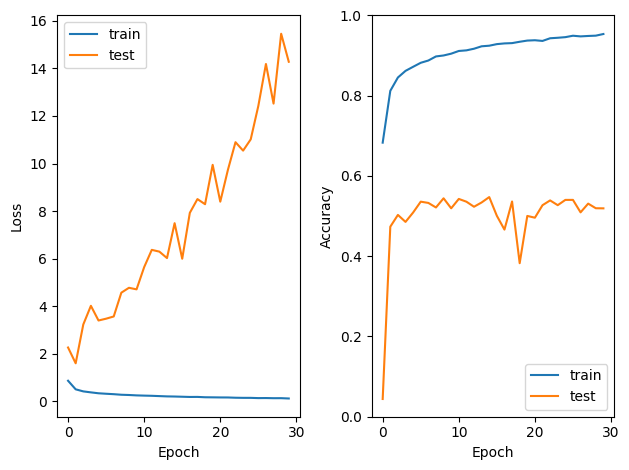

In [29]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_modelv1b.history['loss'])
plt.plot(history_modelv1b.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'test'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_modelv1b.history['accuracy'])
plt.plot(history_modelv1b.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

plt.tight_layout()

In [ ]:
# Save Modelv1b
modelv1b.save("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\MIR-WM811K\\MIR-WM811K\\Python\\modelv1b.keras")

# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_modelv1b.history)

# Save to CSV
history_df.to_csv('history_modelv1b.csv', index=False)

# --- To load it back later ---
#loaded_df = pd.read_csv('history_modelv1b.csv')

### Evaluation ModelV1b

In [23]:
model = tf.keras.models.load_model('modelv1b.keras')
print("Model loaded.")

# 2. Point to the data on your drive (Takes 0 MB of RAM)
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy')
print("Data successfully linked via Memory Map.")

# 3. Test safely using a batch size
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Model loaded.
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5193 - loss: 14.2779

Final Test Accuracy: 51.93%


In [24]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = model.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 2 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [26]:
from sklearn.metrics import confusion_matrix

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Recall:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Recall: {macro_accuracy * 100:.2f}%")

Per-Class Recall:
-------------------------
Class Center: 54.08%
Class Donut: 51.79%
Class Edge-Loc: 47.98%
Class Edge-Ring: 57.75%
Class Loc: 46.24%
Class Near-full: 66.67%
Class Random: 55.17%
Class Scratch: 93.28%
Class none: 51.40%
-------------------------
Average (Macro) Recall: 58.26%


ModelV1b has an accuracy of 51.93%, slighlty lower than ModelV1's 55.18%. ModelV1b has a better performance on Center, Donut, Loc, Random and Scratch than ModelV1, which means using a balanced dataser defintely helps the model to generalize better on minority classes. The main drawback of this approach is that the number of instances belonging to the none class is significantly reduced on the balanced dataset, which leads to a drop to 51.40% in the none class recall. This could be imply that using a balanced dataset with a higher number of samples per class could help to further improve the model's performance.

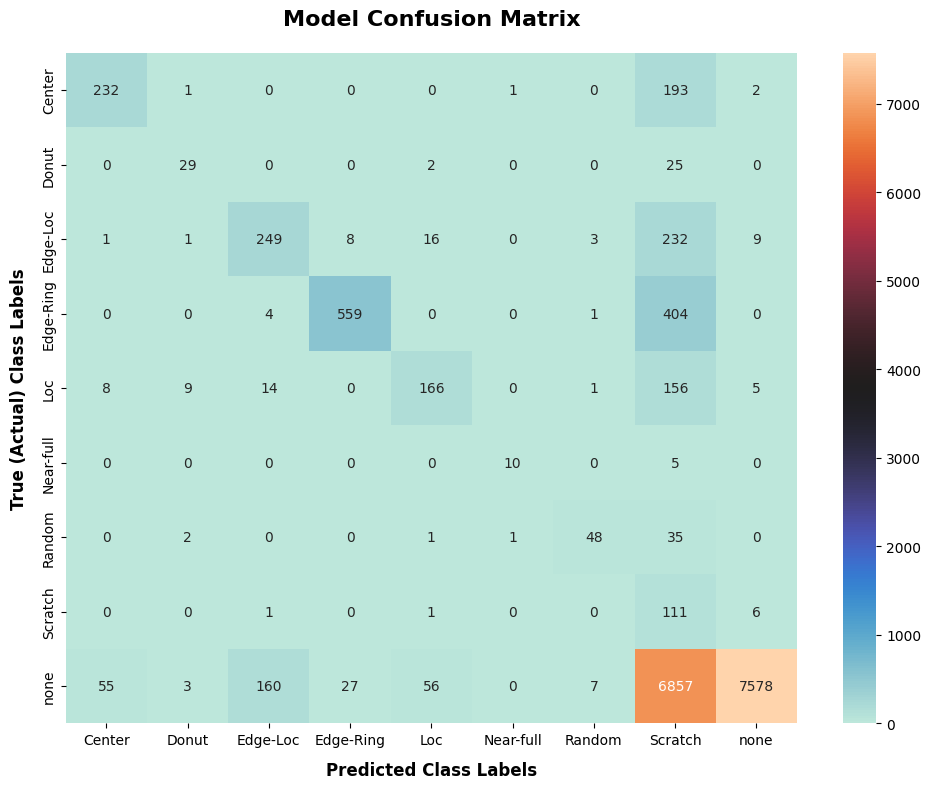

In [6]:
# 1. Calculate the raw confusion matrix numerical values
# (Assumes true_classes and predicted_classes are defined from the predict step)
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Set up the figure size (10x8 inches works well for 9 classes)
plt.figure(figsize=(10, 8))

# 3. Create the colored heatmap
# annot=True plots the numbers inside each square
# fmt='d' forces plain integer format (no scientific notation)
# cmap='Blues' applies a light-to-dark blue gradient based on the numbers
class_names = ClassMapping

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='icefire', 
    xticklabels=class_names, 
    yticklabels=class_names
)

# 4. Add clear labels and styling
plt.title('Model Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class Labels', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True (Actual) Class Labels', fontsize=12, fontweight='bold', labelpad=10)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# 5. Render the plot on your screen
plt.show()

### Model Architecture ModelV2

In [ ]:
num_classes = 9

# Architecture definition (v2)

inputs = keras.Input((54,54,3))

# Slice to keep only the last two channels (indices 1 and 2)
# The syntax [:, :, :, 0:2] means: [batch, height, width, channels 0 through 1]
x = layers.Lambda(lambda x: x[:, :, :, 1:])(inputs)

x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalMaxPooling2D()(x)

outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
modelv2 = keras.Model(inputs, outputs)

In [3]:
modelv2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 54, 54, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 54, 54, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 54, 54, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,689 (76.91 KB)

 Trainable params: 19,689 (76.91 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
modelv2.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Load both the training data and the test data, which we use for validation.

In [4]:
# 1. Clean load using np.load for BOTH files
X_train = np.load('Training_data.npy')
y_train = np.load('Training_labels.dat.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_train.shape, "| Max Value:", X_train.max())
print("Labels (y_train) -> Shape:", y_train.shape, "| Max Value:", y_train.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (31679, 54, 54, 3) | Max Value: 1.0
Labels (y_train) -> Shape: (31679, 9) | Max Value: 1


In [5]:
# 1. Clean load using np.load for BOTH files
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_test.shape, "| Max Value:", X_test.max())
print("Labels (y_train) -> Shape:", y_test.shape, "| Max Value:", y_test.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (17295, 54, 54, 3) | Max Value: 1
Labels (y_train) -> Shape: (17295, 9) | Max Value: 1


In [8]:
print("Train pixel range:", X_train.min(), "to", y_train.max())

Train pixel range: 0.0 to 1


In [9]:
history_modelv2 = modelv2.fit(
    x=X_train,                      # Your 54x54x3 training images
    y=y_train,                      # Your one-hot encoded labels
    epochs=30,                      # MaxEpochs=30
    batch_size=128,                 # MiniBatchSize=128
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch
    
    # --- Handling the Validation Data ---
    # Option A: If you have a SEPARATE validation dataset/labels, uncomment the line below:
    validation_data=(X_test, y_test) 
)

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 34s 131ms/step - accuracy: 0.6795 - loss: 1.0055 - val_accuracy: 0.9045 - val_loss: 0.8194
Epoch 2/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 28s 115ms/step - accuracy: 0.8419 - loss: 0.4572 - val_accuracy: 0.9012 - val_loss: 0.7037
Epoch 3/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.8627 - loss: 0.3852 - val_accuracy: 0.9028 - val_loss: 0.6455
Epoch 4/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.8730 - loss: 0.3496 - val_accuracy: 0.9011 - val_loss: 0.6167
Epoch 5/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 39s 79ms/step - accuracy: 0.8825 - loss: 0.3249 - val_accuracy: 0.8985 - val_loss: 0.6216
Epoch 6/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.8872 - loss: 0.3106 - val_accuracy: 0.9108 - val_loss: 0.5625
Epoch 7/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.8942 - loss: 0.2921 - val_accuracy: 0.9128 - val_loss: 0.5569
Epoch 8/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.8958 - loss: 0.2865 

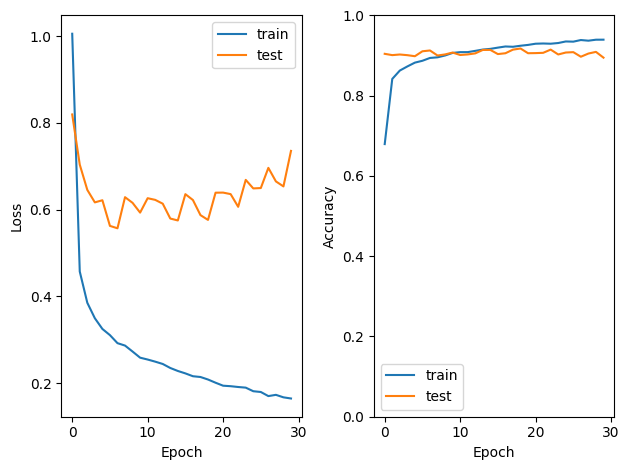

In [10]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_modelv2.history['loss'])
plt.plot(history_modelv2.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'test'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_modelv2.history['accuracy'])
plt.plot(history_modelv2.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

plt.tight_layout()

There seems to be leakage as the model is performing better on the test set than on the training set.

In [11]:
modelv2.save("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\MIR-WM811K\\MIR-WM811K\\Python\\modelv2.keras")

In [ ]:
# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_modelv2.history)

# Save to CSV
history_df.to_csv('history_modelv2.csv', index=False)

# --- To load it back later ---
#loaded_df = pd.read_csv('history_modelv2.csv')

In [30]:
# Pass an empty dictionary or map your specific custom logic if needed
modelv2 = tf.keras.models.load_model(
    'modelv2.keras', 
    custom_objects={'Lambda': tf.keras.layers.Lambda},
    safe_mode=False
)
print("Model loaded.")

# 2. Point to the data on your drive (Takes 0 MB of RAM)
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy')
print("Data successfully linked via Memory Map.")

# 3. Test safely using a batch size
test_loss, test_acc = modelv2.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Model loaded.
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8949 - loss: 0.7354

Final Test Accuracy: 89.49%


In [31]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv2.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 7 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [32]:
from sklearn.metrics import confusion_matrix

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Recall:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Recall: {macro_accuracy * 100:.2f}%")

Per-Class Recall:
-------------------------
Class Center: 47.32%
Class Donut: 44.64%
Class Edge-Loc: 46.63%
Class Edge-Ring: 58.16%
Class Loc: 45.13%
Class Near-full: 66.67%
Class Random: 52.87%
Class Scratch: 40.34%
Class none: 96.17%
-------------------------
Average (Macro) Recall: 55.33%


### Architecture ModelV2b
Modelv2b is ModelV2 trained on the balanced dataset

In [18]:
num_classes = 9

# Architecture definition (v1)

inputs = keras.Input((54,54,3))

# Slice to keep only the last two channels (indices 1 and 2)
# The syntax [:, :, :, 0:2] means: [batch, height, width, channels 0 through 1]
x = layers.Lambda(lambda x: x[:, :, :, 1:3])(inputs)

x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalMaxPooling2D()(x)

outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
modelv2b = keras.Model(inputs, outputs)

In [19]:
modelv2b.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy')
print("Data successfully linked via Memory Map.")

X_balanced = np.load('X_balanced.npy')
y_balanced = np.load('y_balanced.dat.npy')
print("Data successfully linked via Memory Map.")

Data successfully linked via Memory Map.


In [20]:
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_balanced.shape, "| Max Value:", X_balanced.max())
print("Labels (y_train) -> Shape:", y_balanced.shape, "| Max Value:", y_balanced.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (28718, 54, 54, 3) | Max Value: 1.0
Labels (y_train) -> Shape: (28718, 9) | Max Value: 1


IMPORTANT NOTE: ModelV2b will be trained on 20 epochs because ModelV2  started to overfit at around epoch 18.

In [21]:
history_modelv2b = modelv2b.fit(
    x=X_balanced,                      # Your 54x54x3 training images
    y=y_balanced,                      # Your one-hot encoded labels
    epochs=20,                      # MaxEpochs=20
    batch_size=128,                 # MiniBatchSize=128
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch
    
    # --- Handling the Validation Data ---
    # Option A: If you have a SEPARATE validation dataset/labels, uncomment the line below:
    validation_data=(X_test, y_test) 
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.6509 - loss: 1.0552 - val_accuracy: 0.7984 - val_loss: 1.1996
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.7980 - loss: 0.5574 - val_accuracy: 0.8476 - val_loss: 0.9818
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.8293 - loss: 0.4663 - val_accuracy: 0.8646 - val_loss: 0.8983
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.8480 - loss: 0.4181 - val_accuracy: 0.5326 - val_loss: 0.8286
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.8593 - loss: 0.3865 - val_accuracy: 0.5162 - val_loss: 0.8695
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.8632 - loss: 0.3719 - val_accuracy: 0.5171 - val_loss: 0.8378
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.8700 - loss: 0.3528 - val_accuracy: 0.5421 - val_loss: 0.7774
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.8738 - loss: 0.3433 - 

In [22]:
modelv2b.save("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\MIR-WM811K\\MIR-WM811K\\Python\\modelv2b.keras")
# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_modelv2b.history)

# Save to CSV
history_df.to_csv('history_modelv2b.csv', index=False)

# --- To load it back later ---
#loaded_df = pd.read_csv('history_modelv2b.csv')

In [4]:
history_modelv2b = pd.read_csv('history_modelv2b.csv')

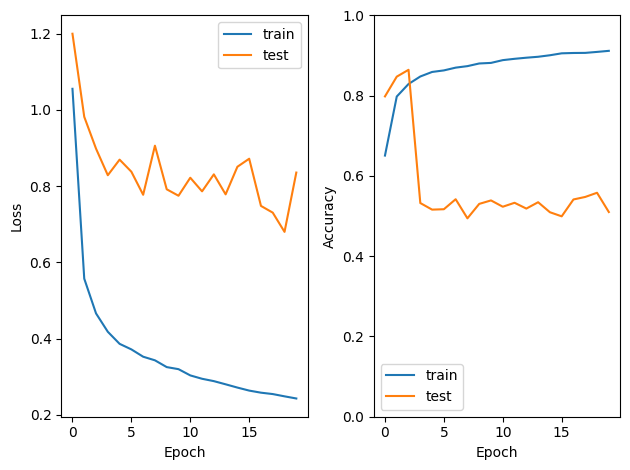

In [6]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_modelv2b['loss'])
plt.plot(history_modelv2b['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'test'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_modelv2b['accuracy'])
plt.plot(history_modelv2b['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

plt.tight_layout()

Even if trained on less epochs ModelV2b still overfits the dataset after a few epochs, which means that either the ModelV2 is not a good model to be used on the balanced dataset or that the balanced dataset has not enough instances to allow the model to properly generalize.

In [ ]:
# Pass an empty dictionary or map your specific custom logic if needed
modelv2b = tf.keras.models.load_model(
    'modelv2b.keras', 
    custom_objects={'Lambda': tf.keras.layers.Lambda},
    safe_mode=False
)
print("Model loaded.")

# 2. Point to the data on your drive (Takes 0 MB of RAM)
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy')
print("Data successfully linked via Memory Map.")

# 3. Test safely using a batch size
test_loss, test_acc = modelv2b.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Model loaded.
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5102 - loss: 0.8356

Final Test Accuracy: 51.02%


In [34]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv2b.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 2 3 2 0 2 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [35]:
from sklearn.metrics import confusion_matrix

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Recall:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Recall: {macro_accuracy * 100:.2f}%")

Per-Class Recall:
-------------------------
Class Center: 51.05%
Class Donut: 46.43%
Class Edge-Loc: 90.56%
Class Edge-Ring: 57.13%
Class Loc: 37.88%
Class Near-full: 66.67%
Class Random: 52.87%
Class Scratch: 45.38%
Class none: 49.58%
-------------------------
Average (Macro) Recall: 55.28%


ModelV2b performs slightly better on the classes Center, Donut and doubles the recall on Edge-Loc, bringing it from 46.63% up to 90.56%. All of this gains in recall are completely overshadowed by the drop in recall in the majority class from 96.17% to 49.58%. The majority class is the class the model has to classify more accurately as it represents most of the data, for this reason the ModelV2 manages to obtain an overall accuracy of 89.49%, while ModelV2 only gets an overall accuracy of 51.02%. Because of this reason we keep ModelV2 is the best model between the two.

### Architecture ModelV3
ModelV3 has the same architecture of modelV2, the only difference is the addition of Batch Normalization at each layer.

In [14]:
num_classes = 9

# Architecture definition (v3)

# 1. Define input size
inputs = keras.Input((54,54,3))

# 2. Lambda Layer: Drop Channel 0 (Background)
    # The slicing [:, :, :, 1:] keeps all batch, height, and width dimensions, 
    # but only keeps channels from index 1 to the end.
x = layers.Lambda(lambda x: x[:, :, :, 1:])(inputs)

# Block 1 (54x54 -> 27x27)
x = layers.Conv2D(32, kernel_size=3, padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=3)(x) 
    
# Block 2 (27x27 -> 13x13)
x = layers.Conv2D(64, kernel_size=3, padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=3)(x)

x = layers.Flatten()(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)
modelv3 = keras.Model(inputs, outputs)

In [15]:
modelv3.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 54, 54, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 54, 54, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 54, 54, 32)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │        20,745 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,137 (156.79 KB)

 Trainable params: 39,945 (156.04 KB)

 Non-trainable params: 192 (768.00 B)

In [16]:
modelv3.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
# 1. Clean load using np.load for BOTH files
X_train = np.load('Training_data.npy')
y_train = np.load('Training_labels.dat.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_train.shape, "| Max Value:", X_train.max())
print("Labels (y_train) -> Shape:", y_train.shape, "| Max Value:", y_train.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (31679, 54, 54, 3) | Max Value: 1.0
Labels (y_train) -> Shape: (31679, 9) | Max Value: 1


In [6]:
# 1. Clean load using np.load for BOTH files
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_test.shape, "| Max Value:", X_test.max())
print("Labels (y_train) -> Shape:", y_test.shape, "| Max Value:", y_test.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (17295, 54, 54, 3) | Max Value: 1
Labels (y_train) -> Shape: (17295, 9) | Max Value: 1


In [17]:
history_modelv3 = modelv3.fit(
    x=X_train,                      # Your 54x54x3 training images
    y=y_train,                      # Your one-hot encoded labels
    epochs=20,                      # MaxEpochs=20
    batch_size=64,                 # MiniBatchSize=64
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch
    
    # --- Handling the Validation Data ---
    validation_data=(X_test, y_test) 
)

Epoch 1/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 73s 143ms/step - accuracy: 0.7061 - loss: 0.9344 - val_accuracy: 0.8880 - val_loss: 0.8449
Epoch 2/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 76s 154ms/step - accuracy: 0.8141 - loss: 0.5503 - val_accuracy: 0.9045 - val_loss: 0.6827
Epoch 3/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 75s 152ms/step - accuracy: 0.8403 - loss: 0.4642 - val_accuracy: 0.9118 - val_loss: 0.6486
Epoch 4/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - accuracy: 0.8561 - loss: 0.4143 - val_accuracy: 0.8896 - val_loss: 0.7282
Epoch 5/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 81s 127ms/step - accuracy: 0.8655 - loss: 0.3879 - val_accuracy: 0.8962 - val_loss: 0.6750
Epoch 6/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 83s 167ms/step - accuracy: 0.8726 - loss: 0.3680 - val_accuracy: 0.9093 - val_loss: 0.5312
Epoch 7/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 136s 156ms/step - accuracy: 0.8797 - loss: 0.3475 - val_accuracy: 0.9059 - val_loss: 0.5125
Epoch 8/20
495/495 ━━━━━━━━━━━━━━━━━━━━ 100s 202ms/step - accuracy: 0.8848 - loss:

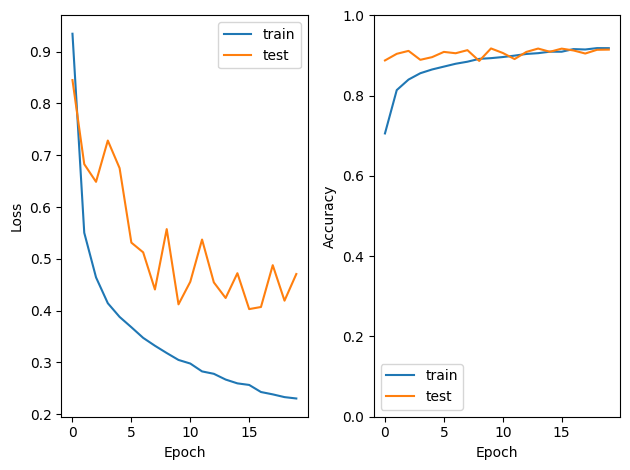

In [18]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_modelv3.history['loss'])
plt.plot(history_modelv3.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'test'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_modelv3.history['accuracy'])
plt.plot(history_modelv3.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

plt.tight_layout()

In [19]:
modelv3.save("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\MIR-WM811K\\MIR-WM811K\\Python\\modelv3.keras")
# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history_modelv3.history)

# Save to CSV
history_df.to_csv('history_modelv3.csv', index=False)

# --- To load it back later ---
#loaded_df = pd.read_csv('history_modelv2b.csv')

In [37]:
modelv3 = tf.keras.models.load_model(
    'modelv3.keras',
    custom_objects={'Lambda': tf.keras.layers.Lambda},
    safe_mode=False)

test_loss, test_acc = modelv3.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9150 - loss: 0.4707

Final Test Accuracy: 91.50%


In [38]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv3.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 4 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [40]:
from sklearn.metrics import confusion_matrix

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Recall:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Recall: {macro_accuracy * 100:.2f}%")

Per-Class Recall:
-------------------------
Class Center: 53.15%
Class Donut: 42.86%
Class Edge-Loc: 48.55%
Class Edge-Ring: 57.54%
Class Loc: 47.35%
Class Near-full: 66.67%
Class Random: 54.02%
Class Scratch: 27.73%
Class none: 98.38%
-------------------------
Average (Macro) Recall: 55.14%


ModelV3 has a slightly better overall accuracy at 91.5% compared to ModelV2's 89.49%. This can be explained by the increase in classification performance in the majority class, 98.38% for ModelV3 against 96.17% for ModelV2. ModelV3 has a slighlty better performance on Center, Edge-Loc, Loc and Random but the major drawback is the drop in recall for Scratch, which goes as low as 27.73%, which is much worse than ModelV2's 40.34%. The change in performance is minimal and if we consider that modelV3 has twice as many parameters than ModelV2, ModelV2 is the better choice.

### Architecture ModelV4
ModelV4 has a similar architecture of ModelV3, but it drops the layer with 64 filters and adds two layers at the beginning, one with 8 filters followed by another one with 16 filters.

In [3]:
num_classes = 9

# Architecture definition (v4)

# 1. Define input size
inputs = keras.Input((54,54,3))

x = layers.Lambda(lambda x: x[:, :, :, 1:])(inputs)

x = layers.Conv2D(8, kernel_size=3, use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(pool_size=3)(x) 

# Block 1 (54x54 -> 27x27)
x = layers.Conv2D(16, kernel_size=3, use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D(pool_size=3)(x) 

# Block 1 (27x27 -> 13x13)
x = layers.Conv2D(32, kernel_size=3, padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=3)(x) 
   
x = layers.Flatten()(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)
modelv4 = keras.Model(inputs, outputs)

In [4]:
modelv4.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 54, 54, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 52, 52, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 52, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 52, 52, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        48,681 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,913 (210.60 KB)

 Trainable params: 53,817 (210.22 KB)

 Non-trainable params: 96 (384.00 B)

In [5]:
modelv4.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
# 1. Clean load using np.load for BOTH files
X_train = np.load('Training_data.npy')
y_train = np.load('Training_labels.dat.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_train.shape, "| Max Value:", X_train.max())
print("Labels (y_train) -> Shape:", y_train.shape, "| Max Value:", y_train.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (31679, 54, 54, 3) | Max Value: 1.0
Labels (y_train) -> Shape: (31679, 9) | Max Value: 1


In [7]:
# 1. Clean load using np.load for BOTH files
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_test.shape, "| Max Value:", X_test.max())
print("Labels (y_train) -> Shape:", y_test.shape, "| Max Value:", y_test.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (17295, 54, 54, 3) | Max Value: 1
Labels (y_train) -> Shape: (17295, 9) | Max Value: 1


In [8]:
history_modelv4 = modelv4.fit(
    x=X_train,                      # Your 54x54x3 training images
    y=y_train,                      # Your one-hot encoded labels
    epochs=30,                      # MaxEpochs=30
    batch_size=64,                 # MiniBatchSize=64
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch
    
    # --- Handling the Validation Data ---
    validation_data=(X_test, y_test) 
)

Epoch 1/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 52s 98ms/step - accuracy: 0.7551 - loss: 0.7369 - val_accuracy: 0.5079 - val_loss: 6.3904
Epoch 2/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 49s 99ms/step - accuracy: 0.8428 - loss: 0.4652 - val_accuracy: 0.5517 - val_loss: 8.2970
Epoch 3/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - accuracy: 0.8703 - loss: 0.3815 - val_accuracy: 0.5404 - val_loss: 9.6488
Epoch 4/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 77s 77ms/step - accuracy: 0.8836 - loss: 0.3397 - val_accuracy: 0.5455 - val_loss: 9.9754
Epoch 5/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - accuracy: 0.8947 - loss: 0.3052 - val_accuracy: 0.5533 - val_loss: 10.0295
Epoch 6/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.9070 - loss: 0.2746 - val_accuracy: 0.5529 - val_loss: 10.3858
Epoch 7/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 34s 70ms/step - accuracy: 0.9140 - loss: 0.2524 - val_accuracy: 0.5500 - val_loss: 9.3470
Epoch 8/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.9183 - loss: 0.2359 

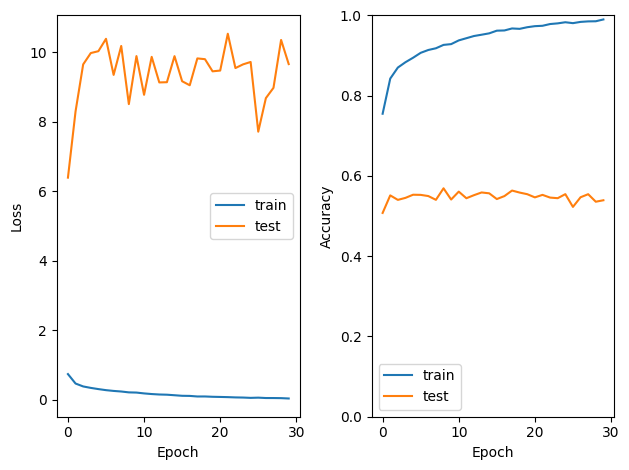

In [9]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_modelv4.history['loss'])
plt.plot(history_modelv4.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'test'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_modelv4.history['accuracy'])
plt.plot(history_modelv4.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

plt.tight_layout()

In [11]:
modelv4.save("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\MIR-WM811K\\MIR-WM811K\\Python\\modelv4.keras")

In [41]:
modelv4 = tf.keras.models.load_model(
    'modelv4.keras', 
    custom_objects={'Lambda': tf.keras.layers.Lambda},
    safe_mode=False
)

test_loss, test_acc = modelv4.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5395 - loss: 9.6582

Final Test Accuracy: 53.95%


In [42]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv4.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 1 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [43]:
from sklearn.metrics import confusion_matrix

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Recall:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Recall: {macro_accuracy * 100:.2f}%")

Per-Class Recall:
-------------------------
Class Center: 51.52%
Class Donut: 50.00%
Class Edge-Loc: 43.35%
Class Edge-Ring: 58.06%
Class Loc: 48.47%
Class Near-full: 53.33%
Class Random: 55.17%
Class Scratch: 63.87%
Class none: 54.19%
-------------------------
Average (Macro) Recall: 53.11%


ModelV4 phas an overall accuracy of 53.95%, which is worse than ModelV2. ModelV4, however has a higher recall than ModelV2 on Center, Donut, Loc, Random and Scratch. The downside to all of this gains in performance is the drop to 54.19% in the none class recall, which leads to the drop in overall accuracy observed. Given that ModelV4 has two times more parameters than ModelV2 and yet performs worse, ModelV2 is a better model than ModelV4.

### Architecture ModelV2a
ModelV2a has the same architecture of ModelV2 with the only difference being the removal of the lambda layer. The purpose of ModelV2a is to assess whether the lambda layer in ModelV2 that allows the CNN to ignore the background, channel 0, is actually helpful at getting more accurate outputs.

In [2]:
num_classes = 9

# Architecture definition (V2a)

inputs = keras.Input((54,54,3))

x = keras.layers.Conv2D(32, 3, padding='same')(inputs)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalMaxPooling2D()(x)

outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
modelv2a = keras.Model(inputs, outputs)

In [19]:
modelv2a.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 54, 54, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 54, 54, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,977 (78.04 KB)

 Trainable params: 19,977 (78.04 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
modelv2a.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [4]:
# 1. Clean load using np.load for BOTH files
X_train = np.load('Training_data.npy')
y_train = np.load('Training_labels.dat.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_train.shape, "| Max Value:", X_train.max())
print("Labels (y_train) -> Shape:", y_train.shape, "| Max Value:", y_train.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (31679, 54, 54, 3) | Max Value: 1.0
Labels (y_train) -> Shape: (31679, 9) | Max Value: 1


In [5]:
# 1. Clean load using np.load for BOTH files
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_test.shape, "| Max Value:", X_test.max())
print("Labels (y_train) -> Shape:", y_test.shape, "| Max Value:", y_test.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (17295, 54, 54, 3) | Max Value: 1
Labels (y_train) -> Shape: (17295, 9) | Max Value: 1


In [6]:
history_modelv2a = modelv2a.fit(
    x=X_train,                      # Your 54x54x3 training images
    y=y_train,                      # Your one-hot encoded labels
    epochs=30,                      # MaxEpochs=30
    batch_size=128,                 # MiniBatchSize=64
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch
    
    # --- Handling the Validation Data ---
    validation_data=(X_test, y_test) 
)

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 29s 108ms/step - accuracy: 0.7168 - loss: 0.8934 - val_accuracy: 0.5572 - val_loss: 1.1830
Epoch 2/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - accuracy: 0.8493 - loss: 0.4201 - val_accuracy: 0.5465 - val_loss: 1.2769
Epoch 3/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 106ms/step - accuracy: 0.8653 - loss: 0.3697 - val_accuracy: 0.5599 - val_loss: 1.1893
Epoch 4/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.8765 - loss: 0.3340 - val_accuracy: 0.5521 - val_loss: 1.2270
Epoch 5/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.8813 - loss: 0.3184 - val_accuracy: 0.5562 - val_loss: 1.1973
Epoch 6/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.8895 - loss: 0.3000 - val_accuracy: 0.5656 - val_loss: 1.1290
Epoch 7/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.8935 - loss: 0.2908 - val_accuracy: 0.5450 - val_loss: 1.2543
Epoch 8/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.8977 - loss: 0.276

In [7]:
modelv2a.save("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\MIR-WM811K\\MIR-WM811K\\Python\\modelv2a.keras")

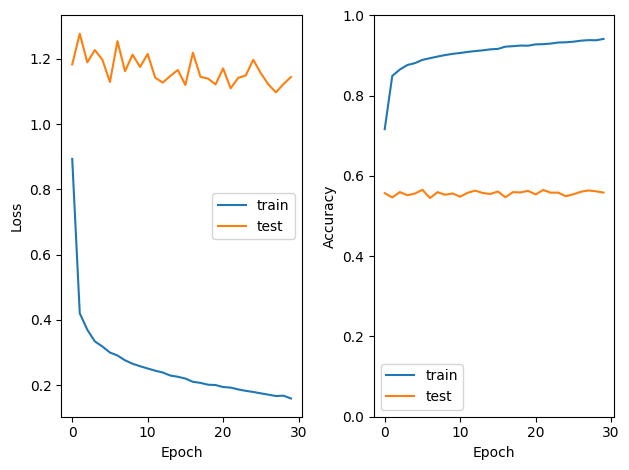

In [8]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_modelv2a.history['loss'])
plt.plot(history_modelv2a.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'test'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_modelv2a.history['accuracy'])
plt.plot(history_modelv2a.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

plt.tight_layout()

In [44]:
modelv2a = tf.keras.models.load_model(
    'modelv2a.keras'
)

test_loss, test_acc = modelv2a.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5587 - loss: 1.1443

Final Test Accuracy: 55.87%


In [45]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv2a.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 7 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [46]:
from sklearn.metrics import confusion_matrix

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Per-Class Recall:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Recall: {macro_accuracy * 100:.2f}%")

Per-Class Recall:
-------------------------
Class Center: 50.82%
Class Donut: 37.50%
Class Edge-Loc: 90.94%
Class Edge-Ring: 57.85%
Class Loc: 44.01%
Class Near-full: 66.67%
Class Random: 51.72%
Class Scratch: 41.18%
Class none: 55.14%
-------------------------
Average (Macro) Recall: 55.09%


ModelV2a has an overall accuracy of 55.87%, worse than ModelV2's 89.49%. Although ModelV2a has a better recall on Center and Edge-Loc, it performs worse than ModelV2 on every class, particularly the majority class with a recall of just 55.14%, which leads to drop in overall accuracy. The result obtained proves that adding a lambda layer, which makes the network ignore the background, improves overall performance.

### Architecture ModelV2w
The following architecture is the same of ModelV2, the only difference is going to be the addition of weight initialization.

In [7]:
num_classes = 9

# Architecture definition (v2)

inputs = keras.Input((54,54,3))

# Slice to keep only the last two channels (indices 1 and 2)
# The syntax [:, :, :, 0:2] means: [batch, height, width, channels 0 through 1]
x = layers.Lambda(lambda x: x[:, :, :, 1:])(inputs)

x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalMaxPooling2D()(x)

outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
modelv2w = keras.Model(inputs, outputs)

In [8]:
modelv2w.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 54, 54, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 54, 54, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 54, 54, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,689 (76.91 KB)

 Trainable params: 19,689 (76.91 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
modelv2w.compile(
    optimizer= keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# 1. Clean load using np.load for BOTH files
X_train = np.load('Training_data.npy')
y_train = np.load('Training_labels.dat.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_train.shape, "| Max Value:", X_train.max())
print("Labels (y_train) -> Shape:", y_train.shape, "| Max Value:", y_train.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (31679, 54, 54, 3) | Max Value: 1.0
Labels (y_train) -> Shape: (31679, 9) | Max Value: 1


In [11]:
# 1. Clean load using np.load for BOTH files
X_test = np.memmap(
    'X_test.dat', dtype='uint8', mode='r', shape=(17295, 54, 54, 3)
)
y_test = np.load('y_test.npy', allow_pickle=True)

# 2. Print the absolute truth about what was inside those files
print("--- THE REALITY CHECK ---")
print("Images (X_train) -> Shape:", X_test.shape, "| Max Value:", X_test.max())
print("Labels (y_train) -> Shape:", y_test.shape, "| Max Value:", y_test.max())

--- THE REALITY CHECK ---
Images (X_train) -> Shape: (17295, 54, 54, 3) | Max Value: 1
Labels (y_train) -> Shape: (17295, 9) | Max Value: 1


In [12]:
# Compute class weights from our augmented data
class_indices = np.argmax(y_train, axis=1)
total = len(class_indices)
num_classes = 9

class_weights = {}
for c in range(num_classes):
    count = np.sum(class_indices == c)
    class_weights[c] = total / (num_classes * count)

# Check what the model will see
ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
print(f"{'Class':<12} {'Count':>8} {'Weight':>8}")
print("-" * 30)
for c in range(num_classes):
    count = np.sum(class_indices == c)
    print(f"{ClassMapping[c]:<12} {count:>8,} {class_weights[c]:>8.3f}")

Class           Count   Weight
------------------------------
Center          3,865    0.911
Donut             499    7.054
Edge-Loc        4,670    0.754
Edge-Ring       8,712    0.404
Loc             3,234    1.088
Near-full         134   26.268
Random            779    4.518
Scratch         1,074    3.277
none            8,712    0.404


In [13]:
history_modelv2w = modelv2w.fit(
    x=X_train,                      # Your 54x54x3 training images
    y=y_train,                      # Your one-hot encoded labels
    epochs=30,                      # MaxEpochs=20
    batch_size=64,                 # MiniBatchSize=64
    shuffle=True,                   # Shuffle="every-epoch"
    verbose=1,                      # Shows a live progress bar for each epoch
    
    # --- Handling the Validation Data ---
    validation_data=(X_test, y_test),

    # Weight initialization
    class_weight = class_weights
)

Epoch 1/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.6269 - loss: 1.1012 - val_accuracy: 0.5308 - val_loss: 1.2124
Epoch 2/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.8061 - loss: 0.6003 - val_accuracy: 0.5400 - val_loss: 1.1006
Epoch 3/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.8366 - loss: 0.4891 - val_accuracy: 0.5076 - val_loss: 1.1076
Epoch 4/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 38s 77ms/step - accuracy: 0.8487 - loss: 0.4476 - val_accuracy: 0.4557 - val_loss: 1.2552
Epoch 5/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.8593 - loss: 0.4116 - val_accuracy: 0.5431 - val_loss: 0.9780
Epoch 6/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.8695 - loss: 0.3754 - val_accuracy: 0.4926 - val_loss: 1.0773
Epoch 7/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.8755 - loss: 0.3537 - val_accuracy: 0.5037 - val_loss: 1.0752
Epoch 8/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.8818 - loss: 0.3382 - 

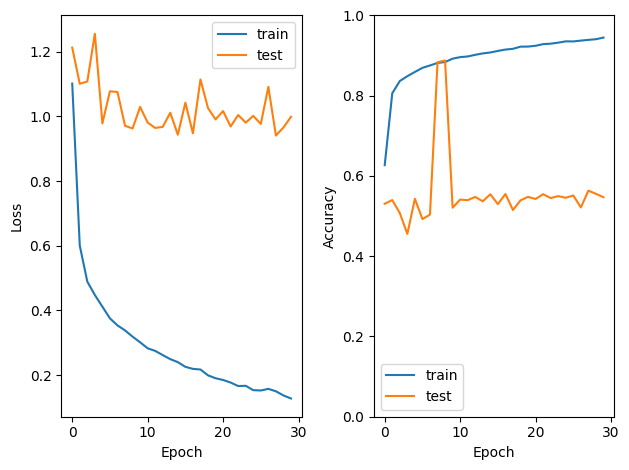

In [14]:
# Visualization of the learning curves
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_modelv2w.history['loss'])
plt.plot(history_modelv2w.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'test'])
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_modelv2w.history['accuracy'])
plt.plot(history_modelv2w.history['val_accuracy'])
plt.ylim([0.0, 1.0])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

plt.tight_layout()

In [18]:
modelv2w.save("C:\\Users\\Utente\\Desktop\\data science\\deep learning\\MIR-WM811K\\MIR-WM811K\\Python\\modelv2w.keras")

In [47]:
modelv2w = tf.keras.models.load_model(
    'modelv2w.keras', 
    custom_objects={'Lambda': tf.keras.layers.Lambda},
    safe_mode=False
)

test_loss, test_acc = modelv2w.evaluate(X_test, y_test, batch_size=128, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.5472 - loss: 0.9984

Final Test Accuracy: 54.72%


In [48]:
print("Generating predictions... This might take a few minutes.")

# 1. Get raw probabilities for all 118,595 images
# The output will be a massive matrix of shape (118595, 9)
predictions = modelv2w.predict(X_test, batch_size=128, verbose=1)

# 2. Convert probabilities into final class choices (0 through 8)
# np.argmax looks at the 9 probabilities for each image and picks the highest one
predicted_classes = np.argmax(predictions, axis=1)

# 3. Convert your one-hot encoded test labels into standard class numbers too
true_classes = np.argmax(y_test, axis=1)

print("\nPredictions generated successfully!")
print(f"First 10 predicted classes: {predicted_classes[:10]}")
print(f"First 10 actual classes:    {true_classes[:10]}")

Generating predictions... This might take a few minutes.
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step

Predictions generated successfully!
First 10 predicted classes: [8 8 8 8 8 3 8 0 7 8]
First 10 actual classes:    [8 8 8 8 8 3 8 0 4 8]


In [49]:
from sklearn.metrics import confusion_matrix

ClassMapping = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"]
predicted_classes = np.argmax(predictions, axis=1)

# 1. Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 2. Calculate per-class accuracy
# cm.diagonal() gets the correctly predicted count for each class
# cm.sum(axis=1) gets the total actual count for each class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# 3. Print the results clearly
print("Recall:")
print("-" * 25)
for class_idx, acc in enumerate(class_accuracies):
    # Grab the actual name from your list using the index
    class_name = ClassMapping[class_idx]
    print(f"Class {class_name}: {acc * 100:.2f}%")
    
# Optional: Print the overall average of these class accuracies (Macro Average)
macro_accuracy = np.mean(class_accuracies)
print("-" * 25)
print(f"Average (Macro) Recall: {macro_accuracy * 100:.2f}%")

Recall:
-------------------------
Class Center: 50.58%
Class Donut: 50.00%
Class Edge-Loc: 92.49%
Class Edge-Ring: 57.33%
Class Loc: 31.20%
Class Near-full: 66.67%
Class Random: 54.02%
Class Scratch: 48.74%
Class none: 53.96%
-------------------------
Average (Macro) Recall: 56.11%


ModelV2w has a higher recall on Center, Donut, Edge-loc and Scratch. ModelV2w, however, performs particularly worse on Loc, which has a 35.38% recall copmared to ModelV2's 45.13%. The recall on none is 91.68%, which doesn't seem a big difference with ModelV2's 96.17%, but it is enough to cause most of the drop in the overall accuracy from 89.49% down to 85.64%.

Although ModelV2w slightly underperforms ModelV2, the fact that it performs better on many of the minority classes, it means that weight initialization helps to deal with the class imbalance problem. This finding suggets that ModelV2 could be further improved if trained on a bigger dataset (e.g using data augmentation).